# Clasificacion de Estilo de Ropa con FashionCLIP

**Modelo**: `patrickjohncyh/fashion-clip` (CLIP fine-tuned en datos de moda)

A diferencia del modelo EfficientNetB0 (que clasifica *tipo* de prenda: tops, shoes, bags...),
FashionCLIP clasifica **estilo** de moda usando similitud texto-imagen.

No requiere reentrenamiento: los estilos se definen como prompts de texto.

---

**Categorias de estilo definidas:**
- Casual / Everyday
- Formal / Business
- Streetwear / Urban
- Bohemian / Free-spirit
- Sporty / Athletic
- Elegant / Evening
- Vintage / Retro
- Minimalist / Clean

In [1]:
# Instalar dependencias necesarias
# transformers: libreria de Hugging Face para cargar FashionCLIP
# torch: backend de PyTorch para el modelo CLIP
%pip install transformers torch torchvision Pillow matplotlib pandas tqdm -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import glob
import math
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
from transformers import CLIPProcessor, CLIPModel
from tqdm import tqdm

# Detectar dispositivo disponible
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo en uso: {DEVICE.upper()}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

C:\Users\Ismael\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dispositivo en uso: CPU


## 1. Cargar FashionCLIP

Se descarga automaticamente desde Hugging Face Hub (~600MB la primera vez, luego queda en cache).

In [3]:
MODEL_NAME = "patrickjohncyh/fashion-clip"

print(f"Cargando modelo: {MODEL_NAME}")
print("(Primera vez: descarga ~600MB desde Hugging Face)")

clip_model = CLIPModel.from_pretrained(MODEL_NAME).to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained(MODEL_NAME)

clip_model.eval()  # Modo inferencia (desactiva dropout, etc.)
print("Modelo cargado correctamente.")

Cargando modelo: patrickjohncyh/fashion-clip
(Primera vez: descarga ~600MB desde Hugging Face)


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 909.94it/s, Materializing param=visual_projection.weight]                                
CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Modelo cargado correctamente.


## 2. Definir Estilos de Moda

Aqui defines los estilos que quieres clasificar. CLIP compara la imagen contra cada
descripcion de texto y devuelve la mas similar.

**Puedes anadir, quitar o modificar estilos sin tocar el modelo.**

In [4]:
# Diccionario: nombre del estilo -> lista de prompts de texto descriptivos
# Usar multiples prompts por estilo mejora la robustez de la clasificacion
FASHION_STYLES = {
    "Casual": [
        "casual everyday clothing",
        "relaxed casual outfit",
        "comfortable everyday wear jeans t-shirt"
    ],
    "Formal": [
        "formal business professional attire",
        "office business suit blazer",
        "professional dress code formal outfit"
    ],
    "Streetwear": [
        "urban streetwear fashion hoodie sneakers",
        "hip hop street style clothing",
        "modern urban youth streetwear outfit"
    ],
    "Bohemian": [
        "bohemian boho free spirit fashion",
        "hippie boho flowy dress natural fabrics",
        "ethnic boho chic festival fashion"
    ],
    "Sporty": [
        "sporty athletic activewear outfit",
        "gym sportswear athletic clothing",
        "athletic performance wear leggings sport"
    ],
    "Elegant": [
        "elegant evening gown formal dress",
        "sophisticated luxury fashion evening wear",
        "chic elegant cocktail dress occasion"
    ],
    "Vintage": [
        "vintage retro 70s 80s fashion style",
        "classic retro vintage inspired outfit",
        "old school vintage aesthetic clothing"
    ],
    "Minimalist": [
        "minimalist clean simple fashion",
        "minimal Scandinavian style neutral colors",
        "clean simple neutral tones minimalist outfit"
    ]
}

# Extraer lista plana de prompts y mapeo de indices a nombre de estilo
style_names = []
all_prompts = []
prompts_per_style = {}

for style, prompts in FASHION_STYLES.items():
    prompts_per_style[style] = list(range(len(all_prompts), len(all_prompts) + len(prompts)))
    all_prompts.extend(prompts)
    style_names.append(style)

print(f"Estilos definidos: {len(FASHION_STYLES)}")
print(f"Total prompts de texto: {len(all_prompts)}")
print()
for style, indices in prompts_per_style.items():
    print(f"  [{style}] ({len(indices)} prompts)")

Estilos definidos: 8
Total prompts de texto: 24

  [Casual] (3 prompts)
  [Formal] (3 prompts)
  [Streetwear] (3 prompts)
  [Bohemian] (3 prompts)
  [Sporty] (3 prompts)
  [Elegant] (3 prompts)
  [Vintage] (3 prompts)
  [Minimalist] (3 prompts)


## 3. Funcion de Clasificacion de Estilo

In [5]:
import torch.nn.functional as F

# Temperatura para el softmax: valores bajos (<1) agudizan la distribucion.
# Con 8 clases, random = 12.5%. T=0.05 separa bien las diferencias de CLIP.
TEMPERATURE = 0.05


def encode_text_prompts(prompts, processor, model, device):
    """
    Pre-codifica todos los prompts de texto una sola vez.
    Devuelve tensor normalizado de features de texto.
    """
    inputs = processor(
        text=prompts,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(device)

    with torch.no_grad():
        output = model.get_text_features(**inputs)

    if not isinstance(output, torch.Tensor):
        output = output.pooler_output if hasattr(output, "pooler_output") and output.pooler_output is not None \
                 else output.last_hidden_state[:, 0, :]

    return F.normalize(output, dim=-1)


def classify_style(img_path, text_features, processor, model, device,
                   prompts_per_style, style_names, temperature=TEMPERATURE):
    """
    Clasifica el estilo de una imagen.

    Args:
        temperature: controla la nitidez del softmax.
                     < 1 → distribucion mas concentrada (mas interpretable)
                     = 1 → softmax estandar (da ~12-14% con 8 clases similares)
    """
    image = Image.open(img_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        output = model.get_image_features(**inputs)

    if not isinstance(output, torch.Tensor):
        output = output.pooler_output if hasattr(output, "pooler_output") and output.pooler_output is not None \
                 else output.last_hidden_state[:, 0, :]

    image_features = F.normalize(output, dim=-1)

    # Similitud coseno imagen vs todos los prompts
    similarities = (image_features @ text_features.T).squeeze(0).cpu().numpy()

    # Agregar por estilo: promedio de similitudes de sus prompts
    style_scores = {
        style: float(np.mean(similarities[indices]))
        for style, indices in prompts_per_style.items()
    }

    # Softmax con temperatura para probabilidades interpretables
    scores_array = np.array([style_scores[s] for s in style_names])
    exp_scores = np.exp((scores_array - scores_array.max()) / temperature)
    probabilities = exp_scores / exp_scores.sum()

    style_probs = {style: float(probabilities[i]) for i, style in enumerate(style_names)}
    top_style = max(style_probs, key=style_probs.get)

    return {
        "top_style": top_style,
        "confidence": style_probs[top_style],
        "scores": style_probs
    }


print("Funciones definidas. Temperature =", TEMPERATURE)
print("Pre-codificando prompts de texto...")
text_features = encode_text_prompts(all_prompts, clip_processor, clip_model, DEVICE)
print(f"Text features shape: {text_features.shape}")
print("Listo.")

Funciones definidas. Temperature = 0.05
Pre-codificando prompts de texto...
Text features shape: torch.Size([24, 512])
Listo.


## 4. Clasificar Imagenes de Test

In [6]:
# Ruta a las imagenes de test (relativa al notebook)
TEST_IMAGES_DIR = os.path.join("..", "data", "external", "test_images")

# Buscar todas las imagenes
extensions = ["*.jpg", "*.jpeg", "*.png", "*.webp"]
image_files = []
for ext in extensions:
    image_files.extend(glob.glob(os.path.join(TEST_IMAGES_DIR, ext)))
    image_files.extend(glob.glob(os.path.join(TEST_IMAGES_DIR, ext.upper())))

image_files = sorted(list(set(image_files)))

if not image_files:
    print(f"No se encontraron imagenes en: {os.path.abspath(TEST_IMAGES_DIR)}")
    print("Verifica la ruta o coloca imagenes en data/external/test_images/")
else:
    print(f"Encontradas {len(image_files)} imagenes en: {os.path.abspath(TEST_IMAGES_DIR)}")

# Clasificar todas las imagenes
results = []
errors = []

for img_path in tqdm(image_files, desc="Clasificando estilos"):
    try:
        result = classify_style(
            img_path,
            text_features,
            clip_processor,
            clip_model,
            DEVICE,
            prompts_per_style,
            style_names
        )
        results.append({
            "archivo": os.path.basename(img_path),
            "estilo": result["top_style"],
            "confianza": f"{result['confidence']:.1%}",
            "ruta": img_path,
            **{f"score_{s}": f"{v:.3f}" for s, v in result["scores"].items()}
        })
    except Exception as e:
        errors.append({"archivo": os.path.basename(img_path), "error": str(e)})
        print(f"Error con {os.path.basename(img_path)}: {e}")

df = pd.DataFrame(results)
print(f"\nClasificacion completada: {len(results)} imagenes procesadas, {len(errors)} errores.")

Encontradas 14 imagenes en: c:\Users\Ismael\Pictures\Nueva carpeta (2)\stylemepal-remote\data\external\test_images


Clasificando estilos: 100%|██████████| 14/14 [00:03<00:00,  3.96it/s]


Clasificacion completada: 14 imagenes procesadas, 0 errores.


## 5. Tabla de Resultados

In [7]:
# Mostrar tabla resumida
cols_resumen = ["archivo", "estilo", "confianza"]
print("Resultados de clasificacion de estilo:")
print("=" * 60)
display(df[cols_resumen])

# Distribucion de estilos predichos
print("\nDistribucion de estilos:")
print("-" * 30)
dist = df["estilo"].value_counts()
for style, count in dist.items():
    bar = "#" * count
    print(f"  {style:<15} {bar} ({count})")

Resultados de clasificacion de estilo:


,archivo,estilo,confianza
0,pexels-aalsaibaie-10853637.jpg,Streetwear,41.7%
1,pexels-alokkd1-19577862.jpg,Streetwear,42.1%
2,pexels-d-ng-thanh-tu-2922122-5693889.jpg,Vintage,27.7%
3,pexels-fahmi-garna-249814583-13094233.jpg,Minimalist,30.8%
4,pexels-ficky-1243617-2364605.jpg,Streetwear,45.3%
5,pexels-ficky-1243617-2364618.jpg,Streetwear,42.8%
6,pexels-fsoerensen-2404959.jpg,Sporty,26.8%
7,pexels-introspectivedsgn-6342786.jpg,Streetwear,23.6%
8,pexels-lappen-fashion-2754326-4295985.jpg,Casual,31.0%
9,pexels-malcolm-garret-3023588-13924893.jpg,Vintage,29.0%



Distribucion de estilos:
------------------------------
  Streetwear      ###### (6)
  Vintage         #### (4)
  Casual          ## (2)
  Minimalist      # (1)
  Sporty          # (1)


## 6. Visualizacion: Imagenes con Estilo Predicho

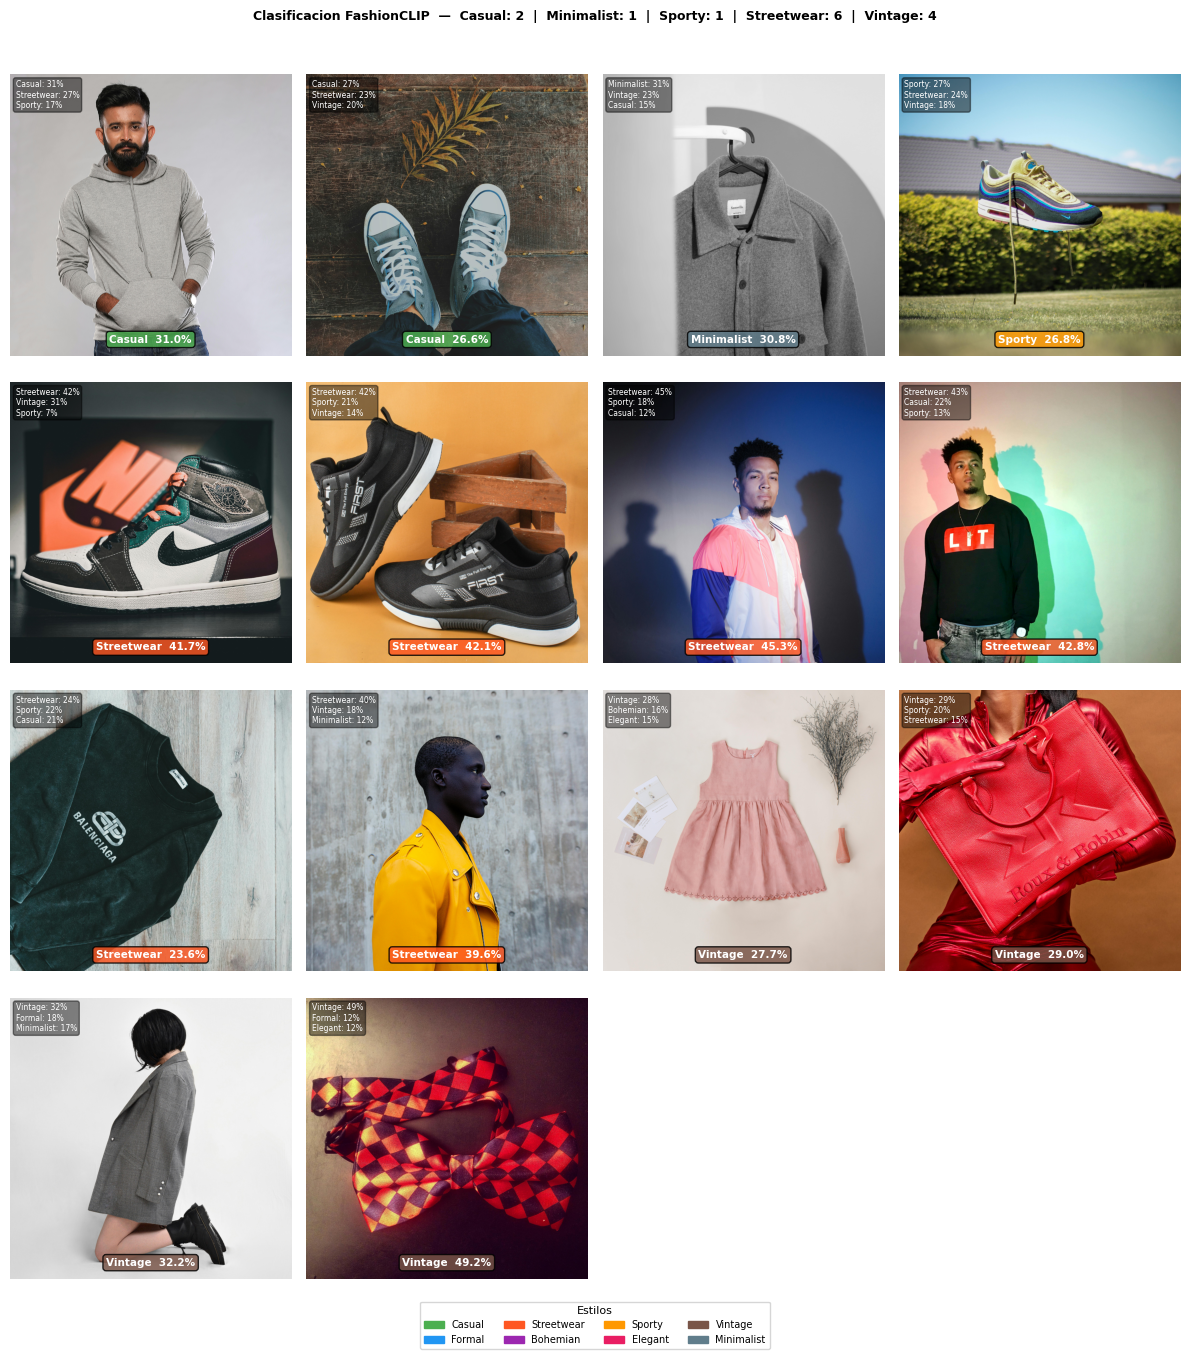

In [8]:
STYLE_COLORS = {
    "Casual":     "#4CAF50",
    "Formal":     "#2196F3",
    "Streetwear": "#FF5722",
    "Bohemian":   "#9C27B0",
    "Sporty":     "#FF9800",
    "Elegant":    "#E91E63",
    "Vintage":    "#795548",
    "Minimalist": "#607D8B",
}


def visualizar_estilos(df, num_cols=4):
    """
    Cuadricula de imagenes agrupadas por estilo.
    - Ordenadas por estilo (todas las del mismo estilo juntas)
    - Etiqueta como overlay en la parte inferior de cada imagen
    - Top-3 estilos como texto pequeño dentro de la imagen
    - Contador de imagenes por estilo en el titulo
    """
    if df is None or len(df) == 0:
        print("No hay resultados para mostrar.")
        return

    # Agrupar por estilo y calcular conteo
    df_sorted = df.sort_values("estilo").reset_index(drop=True)
    counts = df_sorted["estilo"].value_counts().to_dict()
    count_str = "  |  ".join(f"{s}: {n}" for s, n in sorted(counts.items()))

    # Columnas de score para top-3
    score_cols = [c for c in df_sorted.columns if c.startswith("score_")]

    num_imgs = len(df_sorted)
    num_rows = math.ceil(num_imgs / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols,
                             figsize=(num_cols * 3, num_rows * 3.2))
    axes = np.array(axes).flatten()

    for i, row in df_sorted.iterrows():
        ax = axes[i]
        style = row["estilo"]
        color = STYLE_COLORS.get(style, "#444444")

        try:
            img = Image.open(row["ruta"])
            ax.imshow(img)
        except Exception:
            ax.text(0.5, 0.5, "Error", ha="center", va="center",
                    transform=ax.transAxes, fontsize=8)

        # --- Overlay inferior: estilo principal + confianza ---
        ax.text(0.5, 0.04,
                f"{style}  {row['confianza']}",
                transform=ax.transAxes,
                ha="center", va="bottom",
                fontsize=7.5, fontweight="bold", color="white",
                bbox=dict(facecolor=color, alpha=0.82, pad=2,
                          boxstyle="round,pad=0.3"))

        # --- Top-3 como texto minimo en esquina superior izquierda ---
        if score_cols:
            scores = {c.replace("score_", ""): float(row[c]) for c in score_cols}
            top3 = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:3]
            top3_txt = "\n".join(f"{s}: {v:.0%}" for s, v in top3)
            ax.text(0.02, 0.98, top3_txt,
                    transform=ax.transAxes,
                    ha="left", va="top",
                    fontsize=5.5, color="white",
                    bbox=dict(facecolor="black", alpha=0.45, pad=1.5,
                              boxstyle="round,pad=0.3"))

        ax.axis("off")

    for j in range(num_imgs, len(axes)):
        axes[j].axis("off")

    # Leyenda de colores
    patches = [mpatches.Patch(color=c, label=s) for s, c in STYLE_COLORS.items()]
    fig.legend(handles=patches, loc="lower center",
               ncol=4, fontsize=7,
               title="Estilos", title_fontsize=8,
               bbox_to_anchor=(0.5, -0.04))

    plt.suptitle(f"Clasificacion FashionCLIP  —  {count_str}",
                 fontsize=9, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


visualizar_estilos(df)

## 7. Visualizacion: Top-3 Estilos por Imagen

Top-3 estilos para cada imagen:


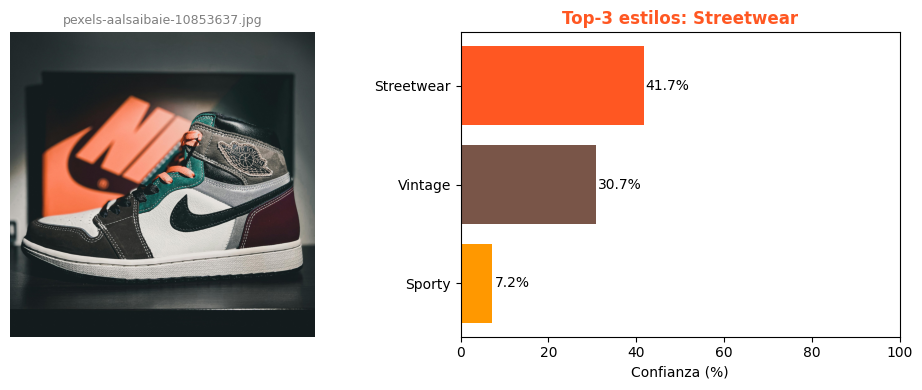

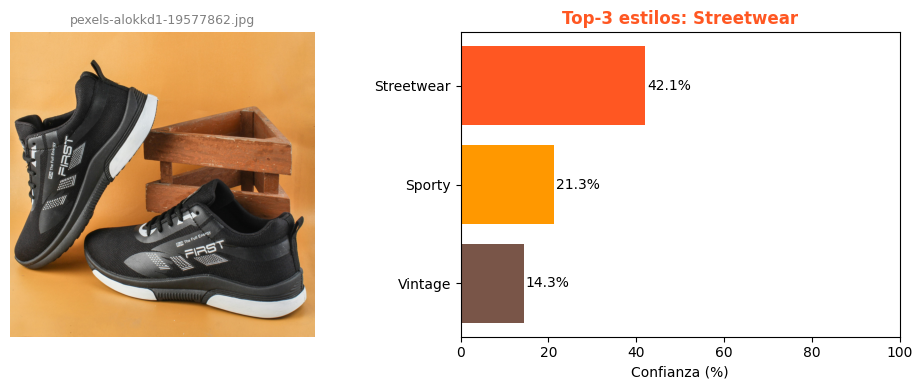

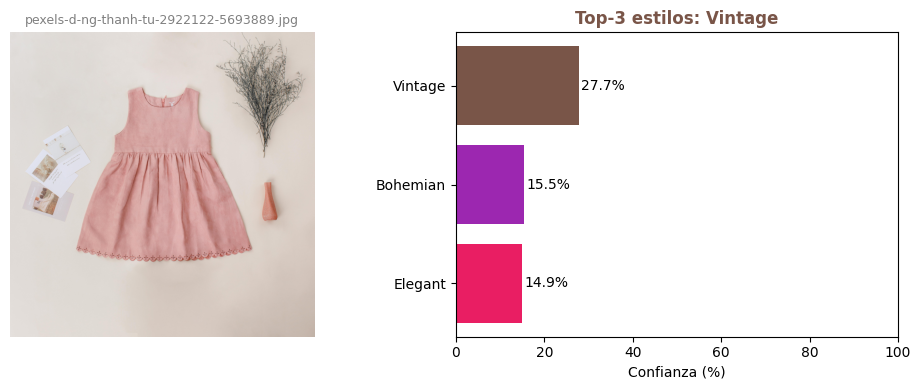

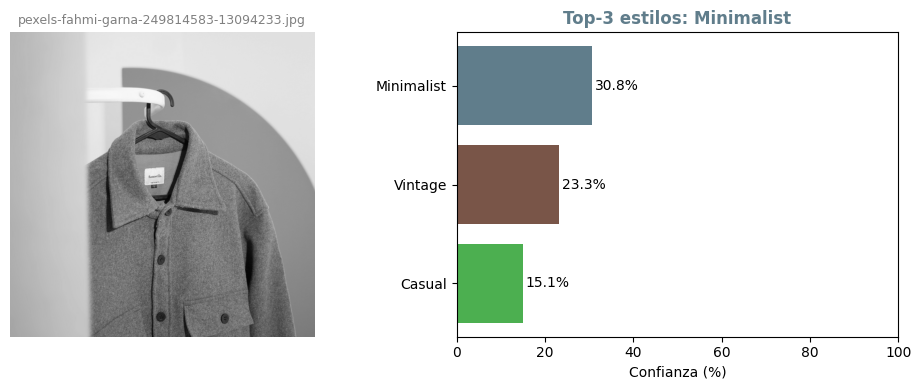

In [9]:
def visualizar_top3(img_path, text_features, processor, model, device,
                    prompts_per_style, style_names, style_colors):
    """
    Para una imagen, muestra la imagen y un grafico de barras
    con el Top-3 de estilos mas probables.
    """
    result = classify_style(
        img_path, text_features, processor, model,
        device, prompts_per_style, style_names
    )

    # Ordenar por score descendente
    sorted_styles = sorted(result["scores"].items(), key=lambda x: x[1], reverse=True)
    top3 = sorted_styles[:3]

    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(10, 4))

    # Imagen
    img = Image.open(img_path).convert("RGB")
    ax_img.imshow(img)
    ax_img.axis("off")
    ax_img.set_title(os.path.basename(img_path), fontsize=9, color="gray")

    # Barras horizontales
    styles_labels = [s for s, _ in top3]
    values = [v * 100 for _, v in top3]
    colors = [style_colors.get(s, "#888") for s in styles_labels]

    bars = ax_bar.barh(styles_labels[::-1], values[::-1], color=colors[::-1])
    ax_bar.set_xlim(0, 100)
    ax_bar.set_xlabel("Confianza (%)")
    ax_bar.set_title(f"Top-3 estilos: {result['top_style']}",
                     fontweight="bold",
                     color=style_colors.get(result['top_style'], "black"))

    # Etiquetas en las barras
    for bar, val in zip(bars, values[::-1]):
        ax_bar.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                    f"{val:.1f}%", va="center", fontsize=10)

    plt.tight_layout()
    plt.show()


# Mostrar top-3 para las primeras 4 imagenes
print("Top-3 estilos para cada imagen:")
for img_path in image_files[:4]:
    visualizar_top3(
        img_path, text_features, clip_processor, clip_model,
        DEVICE, prompts_per_style, style_names, STYLE_COLORS
    )

## 8. Funcion para Clasificar una Imagen Nueva

Usa esta celda para clasificar cualquier imagen que pases como path.

In [10]:
def predecir_estilo(img_path: str) -> dict:
    """
    API simplificada: clasifica el estilo de una imagen.

    Parametros:
        img_path: ruta a la imagen (jpg, png, webp)

    Retorna:
        dict con 'estilo', 'confianza' y 'todos_los_scores'
    """
    result = classify_style(
        img_path, text_features, clip_processor, clip_model,
        DEVICE, prompts_per_style, style_names
    )

    # Mostrar resultado
    print(f"Imagen : {os.path.basename(img_path)}")
    print(f"Estilo : {result['top_style']}")
    print(f"Confianza: {result['confidence']:.1%}")
    print()
    print("Scores por estilo:")
    for style, score in sorted(result["scores"].items(), key=lambda x: x[1], reverse=True):
        bar = "#" * int(score * 40)
        print(f"  {style:<15} {bar:<40} {score:.1%}")

    return {
        "estilo": result["top_style"],
        "confianza": result["confidence"],
        "todos_los_scores": result["scores"]
    }


# --- EJEMPLO DE USO ---
# Cambia esta ruta por cualquier imagen que quieras clasificar
ejemplo = image_files[0] if image_files else "ruta/a/tu/imagen.jpg"
predecir_estilo(ejemplo)

Imagen : pexels-aalsaibaie-10853637.jpg
Estilo : Streetwear
Confianza: 41.7%

Scores por estilo:
  Streetwear      ################                         41.7%
  Vintage         ############                             30.7%
  Sporty          ##                                       7.2%
  Casual          ##                                       6.7%
  Minimalist      #                                        4.8%
  Formal          #                                        3.4%
  Bohemian        #                                        3.2%
  Elegant                                                  2.2%


{'estilo': 'Streetwear',
 'confianza': 0.4166226285609015,
 'todos_los_scores': {'Casual': 0.06733236171259754,
  'Formal': 0.03351957324113109,
  'Streetwear': 0.4166226285609015,
  'Bohemian': 0.032445068298832626,
  'Sporty': 0.0722488433962193,
  'Elegant': 0.022350209440877636,
  'Vintage': 0.30713945475698673,
  'Minimalist': 0.04834186059245371}}

---

## Notas Tecnicas

### Como funciona FashionCLIP

1. **Encoder de imagen**: convierte la imagen a un vector de 512 dimensiones
2. **Encoder de texto**: convierte cada prompt de texto a un vector de 512 dimensiones
3. **Similitud coseno**: mide el angulo entre el vector de imagen y cada vector de texto
4. **Agregacion por estilo**: promedia las similitudes de los prompts del mismo estilo
5. **Softmax**: convierte los scores agregados a probabilidades (suman 1.0)

### Diferencia con EfficientNetB0 entrenado en Polyvore

| Aspecto | EfficientNetB0 (Polyvore) | FashionCLIP |
|---------|--------------------------|-------------|
| Clasifica | Tipo de prenda (tops, shoes...) | Estilo (casual, formal...) |
| Entrenamiento | Supervisado con 251k imagenes | Zero-shot via texto |
| Cambiar categorias | Requiere reentrenamiento | Solo cambia los prompts |
| Precision | 94.65% Top-1 | Depende de los prompts |

### Como mejorar los resultados

- Anadir mas prompts por estilo con descripciones mas especificas
- Ajustar los nombres de estilos al contexto del usuario final
- Combinar con el modelo de tipo de prenda para recomendaciones mas ricas

```python
# Combinacion posible:
# tipo  = EfficientNetB0(imagen)  -> "tops"
# estilo = FashionCLIP(imagen)    -> "Casual"
# resultado: "Casual tops"
```